**Fragment length frequency**

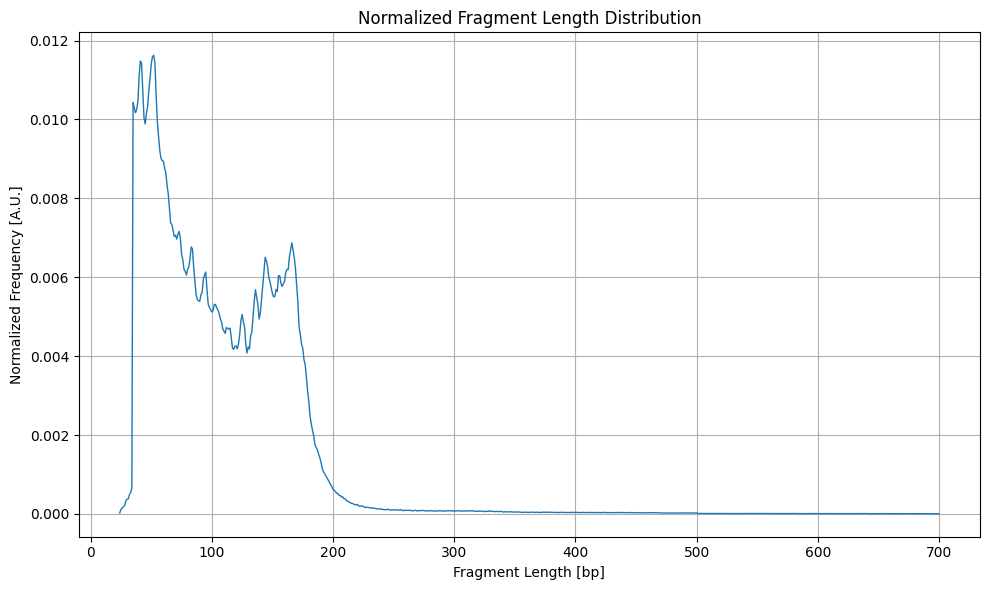

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

fragment_lengths = []

with open("query.bed", "rt") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            start = int(parts[1])
            end = int(parts[2])
            length = end - start
            if length > 0:
                fragment_lengths.append(length)

# Step 2: Count and normalize
counts = Counter(fragment_lengths)
total = sum(counts.values())
normalized_freq = {length: count / total for length, count in counts.items()}

# Convert to DataFrame for plotting
df = pd.DataFrame(list(normalized_freq.items()), columns=["Fragment Length", "Normalized Frequency"])
df.sort_values("Fragment Length", inplace=True)

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.plot(df["Fragment Length"], df["Normalized Frequency"], lw=1)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Normalized Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


**Rescaling**

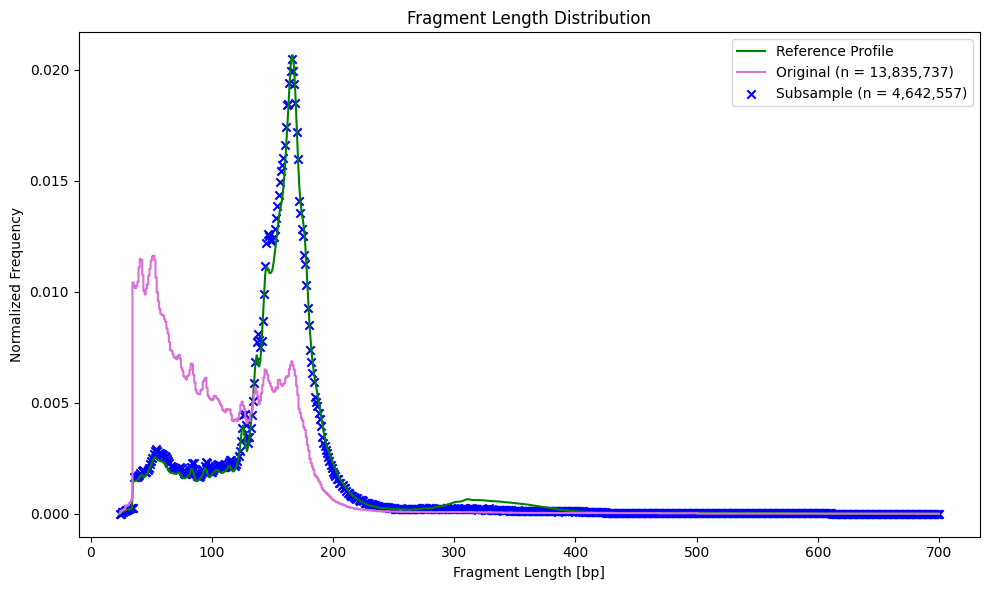

In [7]:
ref_hist = pd.read_csv('reference.hist', sep='\t', header=None, names=['Length', 'Freq'])
input_lengths = pd.DataFrame({'Length': fragment_lengths})
edges = np.append(ref_hist['Length'].values, ref_hist['Length'].values[-1] + 1)
input_lengths['bin_id'] = pd.cut(input_lengths['Length'], bins=edges, labels=False, include_lowest=True)

# Sampling
np.random.seed(42)
selected = []

for bin_index, freq_row in ref_hist.iterrows():
    bin_group = input_lengths[input_lengths['bin_id'] == bin_index]
    if not bin_group.empty:
        sample_size = int(freq_row['Freq'] * len(input_lengths) * 0.38)
        picked = bin_group.sample(n=min(sample_size, len(bin_group)), replace=False)
        selected.append(picked)

# Combine subsampled fragments
sampled_df = pd.concat(selected)

# Normalize histograms
ref_counts = ref_hist['Freq'].values
raw_hist, _ = np.histogram(input_lengths['Length'], bins=edges)
raw_hist_norm = raw_hist / raw_hist.sum()

sampled_hist, _ = np.histogram(sampled_df['Length'], bins=edges)
sampled_hist_norm = sampled_hist / sampled_hist.sum()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(ref_hist['Length'], ref_counts, label='Reference Profile', color='green')
plt.step(edges[:-1], raw_hist_norm, where='mid', label=f'Original (n = {len(input_lengths):,})', color='orchid')
plt.scatter(edges[:-1], sampled_hist_norm, label=f'Subsample (n = {len(sampled_df):,})', color='blue', marker='x')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency')
plt.title('Fragment Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()
